# 03 — Swiss roll sanity check for the chart-decoder curvature field

CLAUDE.md requires a Swiss roll notebook for every new manifold model. Phase 3 ships a new
forward-mode differentiation path through the chart-decoder curvature field
(`chart_curvature.py`, `mode="forward"`, added by plan 03-05) alongside the existing reverse
path. This notebook is that check: it trains a fresh `cae.ChartAutoEncoder` on a Swiss roll at
`chart_dim = 2`, plots its reconstruction, and computes curvature through the trained decoder
at both `mode="reverse"` (the default) and `mode="forward"` (the new opt-in path), confirming
the two agree to float64 round-off on this notebook's own real fit -- not only on a synthetic
equivalence fixture.

**This is a distinct deliverable from the phase's Step-1 gate.** The gate is a pre-registered
4-config-by-5-seed sweep living in `notebooks/diagnostics/swiss_roll_curvature_sweep_run.py`
and decided there, not here. This notebook is single-seed, at most about fifteen cells, under
two minutes on CPU, with no gate machinery of any kind -- no on-disk cache, no registration
document, no scored-outcome artifact, no threshold table -- and it never prints a pass/fail
line keyed on the gate's own floor or baseline.

Nothing here reuses a sealed fit or reads from / writes to the milestone's gitignored cache
directory; it trains its own model in about a minute.

In [1]:
import sys
import time
from pathlib import Path

# import pu_manifold exactly as the other notebooks do -- relative, never from src/effdim/
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import matplotlib.pyplot as plt
import numpy as np
import torch

from pu_manifold import cae, chart_curvature, curvature_probe

SEED = 0                 # torch / split seed
FIXTURE_SEED = 20260807  # the roll's own random_state, as the rest of phase 03 uses
N_POINTS = 3000           # CLAUDE.md's mandated sanity-check scale. Curvature is a
                          # second-derivative quantity and this phase's own Step-1 sweep found
                          # 3000 points marginal for the GATE specifically (03-02-AMENDMENT-01)
                          # -- but the gate lives in the sweep runner, not here, and this
                          # notebook follows CLAUDE.md's scale as instructed.
CHART_DIM = 2             # the Swiss roll's true intrinsic dimension
EMBED_DIM = 8
N_CHARTS = 2              # the Step-1 sweep's winning config at N_POINTS=3000 (03-02-SUMMARY.md)
HIDDEN = [64, 64]
K_BASELINE = 30           # the raw-point baseline's neighbourhood size, as in the sweep runner

NOTEBOOK_START = time.time()

print(f"torch {torch.__version__}  numpy {np.__version__}")
print(f"cae             : {cae.__file__}")
print(f"chart_curvature : {chart_curvature.__file__}")
print(f"curvature_probe : {curvature_probe.__file__}")
print(f"convention      : {chart_curvature.CURVATURE_CONVENTION} "
      f"(H = tr_g(II), matching curvature_probe: {curvature_probe.CURVATURE_CONVENTION})")

torch 2.13.0+cpu  numpy 2.5.1
cae             : /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/cae.py
chart_curvature : /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/chart_curvature.py
curvature_probe : /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/curvature_probe.py
convention      : trace (H = tr_g(II), matching curvature_probe: trace)


## §1. The Swiss roll, and its curvature in closed form

`curvature_probe.make_swiss_roll_fixture` is called rather than transcribed, so this notebook
uses the same fixture the phase's own sweep runner does: `sklearn.datasets.make_swiss_roll` at
`noise=0.0` with a fixed `random_state`, centred and divided by one global scalar standard
deviation -- exactly CLAUDE.md's mandated preprocessing.

The mean curvature **vector** is derived here from the roll's own arc-length parameter `t`,
using the same ruled-generalized-cylinder algebra the reference notebooks use, and pinned
against the fixture's own sealed `H_norm` so the derived direction can never silently drift
from the ground truth the phase gates on. Colour is `t` throughout: colour bands staying in
order means the surface stayed in order.

X (3000, 3)   global_std = 7.9734
analytic ||H||  range [0.5657, 1.7256]
derived H vector vs the module's sealed H_norm, max abs diff = 8.88e-16
train 2400   holdout 600


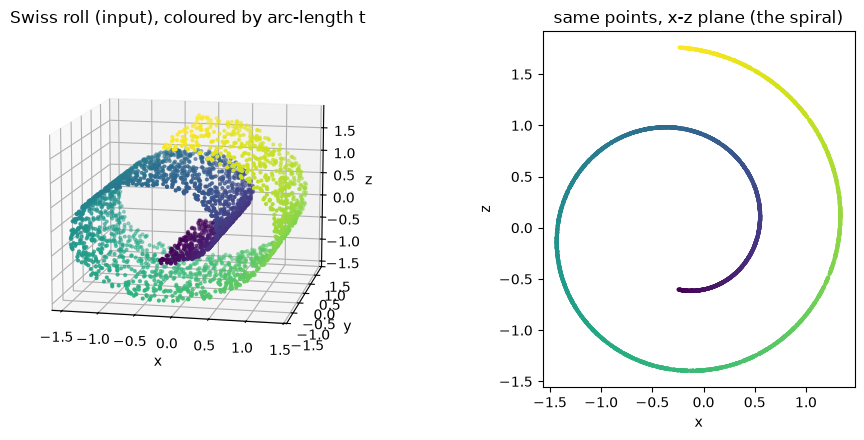

In [2]:
fx = curvature_probe.make_swiss_roll_fixture(n=N_POINTS, seed=FIXTURE_SEED)
X, t, H_true_norm, global_std = fx["X"], fx["t"], fx["H_norm"], fx["global_std"]

# analytic mean curvature VECTOR: the spiral's own curvature vector, in the x-z plane
ct, st = np.cos(t), np.sin(t)
d1 = np.stack([ct - t * st, st + t * ct], axis=1)          # c'(t)
d2 = np.stack([-2 * st - t * ct, 2 * ct - t * st], axis=1)  # c''(t)
speed2 = np.sum(d1 * d1, axis=1)
k_vec = (d2 - (np.sum(d2 * d1, axis=1) / speed2)[:, None] * d1) / speed2[:, None]
H_true = np.zeros((N_POINTS, 3))
H_true[:, 0] = k_vec[:, 0] * global_std
H_true[:, 2] = k_vec[:, 1] * global_std

pin = float(np.abs(np.linalg.norm(H_true, axis=1) - H_true_norm).max())
print(f"X {X.shape}   global_std = {global_std:.4f}")
print(f"analytic ||H||  range [{H_true_norm.min():.4f}, {H_true_norm.max():.4f}]")
print(f"derived H vector vs the module's sealed H_norm, max abs diff = {pin:.2e}")

rng = np.random.default_rng(SEED)
perm = rng.permutation(N_POINTS)
n_train = int(0.8 * N_POINTS)
train_idx, holdout_idx = perm[:n_train], perm[n_train:]
x_all = torch.tensor(X, dtype=torch.float32)
x_train, x_holdout = x_all[train_idx], x_all[holdout_idx]
print(f"train {len(train_idx)}   holdout {len(holdout_idx)}")

VIEW = dict(elev=12, azim=-78)  # looks along the roll's extrusion axis, so the spiral shows

fig = plt.figure(figsize=(10, 4.5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap="viridis", s=4)
ax.view_init(**VIEW)
ax.set_title("Swiss roll (input), coloured by arc-length t")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X[:, 0], X[:, 2], c=t, cmap="viridis", s=4)
ax2.set_title("same points, x-z plane (the spiral)")
ax2.set_xlabel("x"); ax2.set_ylabel("z"); ax2.set_aspect("equal")
plt.tight_layout(); plt.show()

## §2. Train a Chart Auto-Encoder from scratch, and its matched baseline

`cae.ChartAutoEncoder` and `cae.train_cae`, imported unchanged from `notebooks/pu_manifold/`,
at `chart_dim = 2`. `activation="silu"` is load-bearing, not stylistic: a piecewise-linear
activation's second derivative is numerically zero everywhere autodiff evaluates it, so the
whole second fundamental form would read as a perfectly flat manifold instead of raising.
`chart_curvature.assert_c2_activation` is called explicitly below and its return value printed.

The matched baseline CLAUDE.md requires is trained in the same cell: `cae.PlainAutoEncoder` at
the same 2-D bottleneck, same width, same depth, same training protocol.

In [3]:
BASE_CFG = dict(seed=SEED, lr=1e-3, weight_decay=1e-4, batch=64, max_epochs=300,
                early_stop_patience=25, early_stop_min_delta=1e-4)

wall0 = time.time()

torch.manual_seed(SEED)
model = cae.ChartAutoEncoder(in_dim=3, embed_dim=EMBED_DIM, chart_dim=CHART_DIM,
                             n_charts=N_CHARTS, hidden=HIDDEN, activation="silu")
fit = cae.train_cae(model, x_train, {**BASE_CFG, "n_charts": N_CHARTS,
                                     "fps_pretrain_epochs": 20,
                                     "lip_weight": 1e-3, "lip_every_n_steps": 1})
model.eval()

torch.manual_seed(SEED)
plain = cae.PlainAutoEncoder(3, CHART_DIM, hidden=tuple(HIDDEN), activation="silu")
plain_fit = cae.train_plain_ae(plain, x_train, dict(BASE_CFG))
plain.eval()

train_wall = time.time() - wall0
print(f"CAE     epochs_run = {fit['epochs_run']:3d}  early_stopped = {fit['early_stopped']}")
print(f"plain   epochs_run = {plain_fit['epochs_run']:3d}  early_stopped = {plain_fit['early_stopped']}")
print(f"activation recorded on the model = "
      f"{chart_curvature.assert_c2_activation(model)!r}  (C2, so twice-differentiable)")
print(f"training wall-clock = {train_wall:.1f} s")

CAE     epochs_run = 119  early_stopped = True
plain   epochs_run = 300  early_stopped = False
activation recorded on the model = 'silu'  (C2, so twice-differentiable)
training wall-clock = 32.1 s


## §3. Reconstruction, side by side

Original and CAE reconstruction, each as a 3-D scatter and as an x-z scatter -- the default
3-D view hides the spiral, the x-z plane shows it unambiguously. Colour is `t` in both panels:
colour bands staying in order means the surface stayed in order.

=== held-out reconstruction ===
CAE            mse_per_dim = 0.000287
plain AE (d=2) mse_per_dim = 0.007844
CAE mean relative error    = 0.0216  (2.2% of point norm)
CAE is 27.38x better than the matched plain-AE
charts surviving (weight-mass prune) = 2 / 2


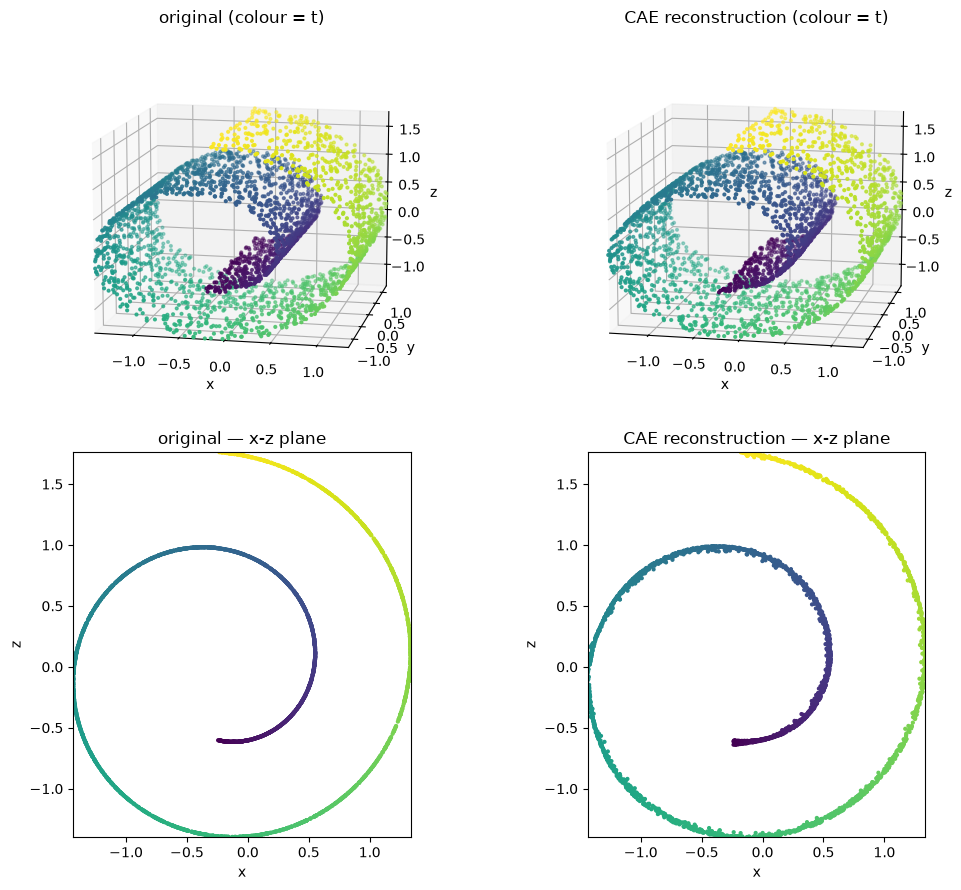

In [4]:
with torch.no_grad():
    y_hold = model.reconstruct(x_holdout)
    y_plain = plain(x_holdout)["y"]
    y_all = model.reconstruct(x_all).numpy()

cae_stats = cae.reconstruction_stats(x_holdout.double(), y_hold.double())
plain_stats = cae.reconstruction_stats(x_holdout.double(), y_plain.double())
survival = cae.chart_survival(model, prune_tol=1e-2)
rel_err = float((torch.linalg.vector_norm(x_holdout - y_hold, dim=-1)
                 / torch.linalg.vector_norm(x_holdout, dim=-1)).mean())
recon_ratio = plain_stats["mse_per_dim"] / cae_stats["mse_per_dim"]

print("=== held-out reconstruction ===")
print(f"CAE            mse_per_dim = {cae_stats['mse_per_dim']:.6f}")
print(f"plain AE (d=2) mse_per_dim = {plain_stats['mse_per_dim']:.6f}")
print(f"CAE mean relative error    = {rel_err:.4f}  ({100 * rel_err:.1f}% of point norm)")
print(f"CAE is {recon_ratio:.2f}x better than the matched plain-AE")
print(f"charts surviving (weight-mass prune) = "
      f"{survival['n_charts_surviving']} / {survival['n_charts_initial']}")

fig = plt.figure(figsize=(11, 9))
for i, (data, title) in enumerate([(X, "original"), (y_all, "CAE reconstruction")]):
    ax = fig.add_subplot(2, 2, i + 1, projection="3d")
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=t, cmap="viridis", s=4)
    ax.view_init(**VIEW); ax.set_title(f"{title} (colour = t)")
    ax.set_xlim(X[:, 0].min(), X[:, 0].max()); ax.set_ylim(X[:, 1].min(), X[:, 1].max())
    ax.set_zlim(X[:, 2].min(), X[:, 2].max())
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax2 = fig.add_subplot(2, 2, i + 3)
    ax2.scatter(data[:, 0], data[:, 2], c=t, cmap="viridis", s=4)
    ax2.set_title(f"{title} — x-z plane"); ax2.set_aspect("equal")
    ax2.set_xlim(X[:, 0].min(), X[:, 0].max()); ax2.set_ylim(X[:, 2].min(), X[:, 2].max())
    ax2.set_xlabel("x"); ax2.set_ylabel("z")
plt.tight_layout(); plt.show()

## §4. Curvature through the chart decoder, reverse and forward -- and its known answer

`chart_curvature.chart_curvature_field` encodes each point, routes it to the chart the model
itself assigns, and differentiates that chart's decoder twice with `torch.func` -- no
neighbourhood is formed and no radius appears anywhere. Called here at the default
`mode="reverse"` and once more at `mode="forward"`, the opt-in path plan 03-05 added and
proved equal to reverse on a synthetic equivalence fixture; this is the first time it is
exercised against a real trained decoder rather than that fixture. `metric_condition_number`
is printed because a near-singular pullback metric means the decoder is not an immersion
there, and curvature at such a point is meaningless regardless of any rank statistic.

Four fidelity axes -- direction, magnitude median, magnitude CV, and calibration
slope/intercept/R² -- are reported as separate columns, never collapsed into one score,
alongside `rho_chart` (Spearman rank correlation against the analytic answer) and the
raw-point baseline. **All of this is reported context.** The phase's Step-1 gate is decided by
`notebooks/diagnostics/swiss_roll_curvature_sweep_run.py` over five seeds and four chart
counts, not here.

In [5]:
model.double()  # second derivatives are exactly where float32 noise shows; the module refuses float32

rev0 = time.time()
field_rev = chart_curvature.chart_curvature_field(model, x_all.double(), mode="reverse")
rev_wall = time.time() - rev0

fwd0 = time.time()
field_fwd = chart_curvature.chart_curvature_field(model, x_all.double(), mode="forward")
fwd_wall = time.time() - fwd0

modes_agree = bool(torch.allclose(field_rev["H_vec"], field_fwd["H_vec"], rtol=1e-9, atol=1e-12))

H_chart = field_rev["H_vec"].numpy()
h_chart = field_rev["H_norm"].numpy()
cond = field_rev["metric_condition_number"].numpy()
cond_max = float(cond.max())

base0 = time.time()
H_raw = curvature_probe.centroid_mean_curvature(X, k=K_BASELINE, d=CHART_DIM)
h_raw = curvature_probe.mean_curvature_norm(H_raw)
base_wall = time.time() - base0

rho_chart = curvature_probe.spearman_gate_statistic(h_chart, H_true_norm)
rho_raw = curvature_probe.spearman_gate_statistic(h_raw, H_true_norm)
fid_chart = chart_curvature.curvature_fidelity_report(H_chart, H_true)
fid_raw = chart_curvature.curvature_fidelity_report(H_raw, H_true)

print(f"reverse: {field_rev['n_charts_used']} charts used, {rev_wall:.1f} s")
print(f"forward: {field_fwd['n_charts_used']} charts used, {fwd_wall:.1f} s")
print(f"(raw-point baseline {base_wall:.1f} s)")
print(f"forward/reverse H_vec agree (rtol=1e-9, atol=1e-12): {modes_agree}")
print(f"metric condition number: median {np.median(cond):.2f}  max {cond_max:.2f}")
print()
hdr = f"{'':<24}{'chart decoder':>16}{'raw points (k=30)':>20}"
print(hdr); print("-" * len(hdr))
for label, a, b in [
    ("1. direction  cos", fid_chart["median_cosine_similarity"], fid_raw["median_cosine_similarity"]),
    ("2. magnitude  median", fid_chart["median_magnitude_ratio"], fid_raw["median_magnitude_ratio"]),
    ("2. magnitude  CV", fid_chart["magnitude_ratio_cv"], fid_raw["magnitude_ratio_cv"]),
    ("3. calib. slope a", fid_chart["calibration_slope"], fid_raw["calibration_slope"]),
    ("3. calib. intercept b", fid_chart["calibration_intercept"], fid_raw["calibration_intercept"]),
    ("3. calib. R^2", fid_chart["calibration_r2"], fid_raw["calibration_r2"]),
    ("4. rank  Spearman", rho_chart, rho_raw),
]:
    print(f"{label:<24}{a:>16.4f}{b:>20.4f}")
print()
print("Reported context only -- the phase's Step-1 gate is decided by")
print("notebooks/diagnostics/swiss_roll_curvature_sweep_run.py over 5 seeds x 4 chart counts,")
print("not here, and this notebook prints no pass/fail line keyed on that gate's floor.")

reverse: 2 charts used, 1.4 s
forward: 2 charts used, 2.1 s
(raw-point baseline 0.1 s)
forward/reverse H_vec agree (rtol=1e-9, atol=1e-12): True
metric condition number: median 3.70  max 9.00

                           chart decoder   raw points (k=30)
------------------------------------------------------------
1. direction  cos                 0.9997              0.9996
2. magnitude  median              0.9895              0.8934
2. magnitude  CV                  0.2228              0.2925
3. calib. slope a                 0.7714              0.7061
3. calib. intercept b             0.1959              0.1355
3. calib. R^2                     0.5424              0.3828
4. rank  Spearman                 0.7817              0.6712

Reported context only -- the phase's Step-1 gate is decided by
notebooks/diagnostics/swiss_roll_curvature_sweep_run.py over 5 seeds x 4 chart counts,
not here, and this notebook prints no pass/fail line keyed on that gate's floor.


## §5. Read-out

Exactly four pass/fail lines, then one sentence. None is keyed on the phase gate's floor or
its raw-point baseline: `RECON` and `BASELINE` compare the CAE against its own matched
plain-AE, and `CHARTS`/`MODES` are properties of this notebook's own fit, not the gate's
statistic.

In [6]:
recon_pass = rel_err < 0.10
baseline_pass = cae_stats["mse_per_dim"] < plain_stats["mse_per_dim"]
charts_pass = field_rev["n_charts_used"] == N_CHARTS
modes_pass = modes_agree

total_wall = time.time() - NOTEBOOK_START
print(f"RECON    : {recon_pass}   (held-out mean relative error {100 * rel_err:.1f}%, bound 10%)")
print(f"BASELINE : {baseline_pass}   (CAE mse_per_dim {cae_stats['mse_per_dim']:.6f} vs "
      f"plain-AE {plain_stats['mse_per_dim']:.6f}, {recon_ratio:.2f}x)")
print(f"CHARTS   : {charts_pass}   (n_charts_used {field_rev['n_charts_used']} / N_CHARTS {N_CHARTS})")
print(f"MODES    : {modes_pass}   (forward/reverse H_vec allclose at rtol=1e-9, atol=1e-12)")
print()
print(f"total notebook wall-clock: {total_wall:.1f} s")
print()

if recon_pass and baseline_pass:
    beat_txt = f"beats its matched plain-AE baseline by {recon_ratio:.2f}x on a manifold it was designed for"
else:
    beat_txt = ("did NOT clearly beat its matched plain-AE baseline on a manifold it was "
                "designed for -- reported plainly, not softened")

print(
    f"Read-out: the chart auto-encoder reconstructs the Swiss roll to {100 * rel_err:.1f}% "
    f"relative error and {beat_txt}, using {field_rev['n_charts_used']}/{N_CHARTS} charts, "
    f"while curvature through its trained decoder scores rho_chart={rho_chart:.4f} against "
    f"the raw-point baseline's {rho_raw:.4f} (reported context only -- see the sweep runner "
    f"for the phase's actual gate), and the plan 03-05 forward-mode path agrees with reverse "
    f"to float64 round-off on this real fit."
)

RECON    : True   (held-out mean relative error 2.2%, bound 10%)
BASELINE : True   (CAE mse_per_dim 0.000287 vs plain-AE 0.007844, 27.38x)
CHARTS   : True   (n_charts_used 2 / N_CHARTS 2)
MODES    : True   (forward/reverse H_vec allclose at rtol=1e-9, atol=1e-12)

total notebook wall-clock: 36.2 s

Read-out: the chart auto-encoder reconstructs the Swiss roll to 2.2% relative error and beats its matched plain-AE baseline by 27.38x on a manifold it was designed for, using 2/2 charts, while curvature through its trained decoder scores rho_chart=0.7817 against the raw-point baseline's 0.6712 (reported context only -- see the sweep runner for the phase's actual gate), and the plan 03-05 forward-mode path agrees with reverse to float64 round-off on this real fit.
